# EN3160 Assignment 01

## T.S.R.Peiris- 230470U
### Question 1 



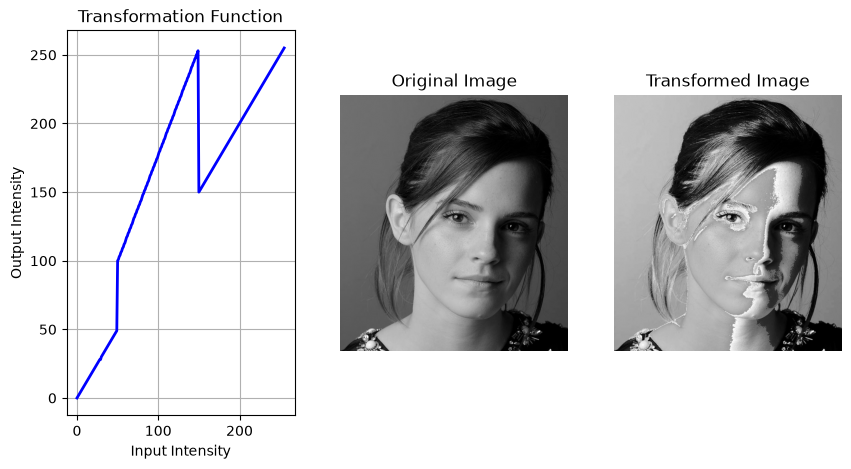

In [83]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
f = cv.imread('images/emma.jpg', cv.IMREAD_GRAYSCALE)
def transform(breakpoints):
    t = np.zeros(256, dtype=np.uint8)
    for i in range(len(breakpoints) - 1):
        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]
        if x1 == x2:
            t[x1] = y1
        else:
            for x in range(x1, x2 + 1):
                t[x] = y1 + (y2 - y1) * ((x - x1) / (x2 - x1))
    return t
points = [
    (0, 0),
    (50, 50),
    (50, 100),
    (150, 255),
    (150, 150),
    (255, 255)
]
t = transform(points)
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].plot(np.arange(256), t, 'b-', linewidth=2)
ax[0].grid()
ax[0].set_title('Transformation Function')
ax[0].set_xlabel('Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[1].imshow(f, cmap='gray')
ax[1].set_title('Original Image')
ax[1].axis('off')
f_transformed = cv.LUT(f, t)
ax[2].imshow(f_transformed, cmap='gray')    
ax[2].set_title('Transformed Image')
ax[2].axis('off')
plt.show()




The transformation points were selected to increase mid intensity pixel values.

## Question 2

Text(0, 0.5, 'Output Intensity')

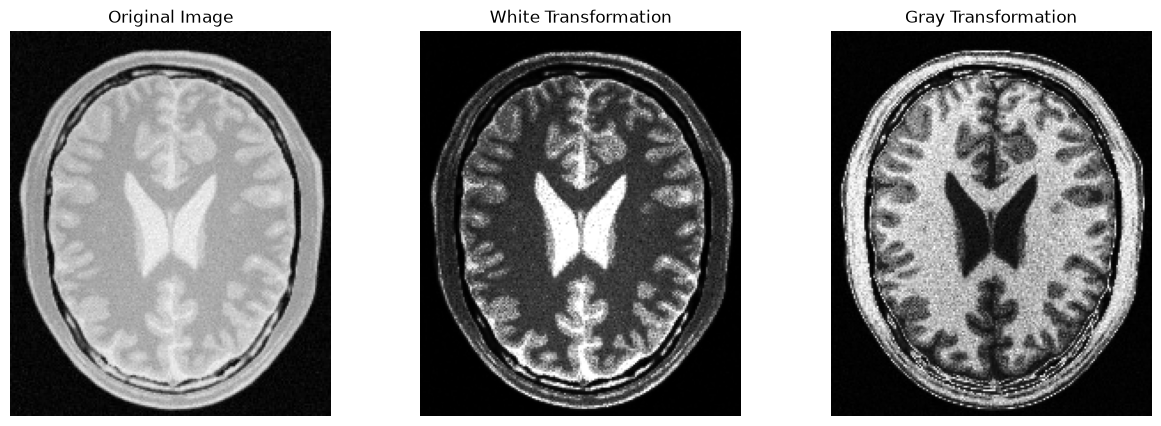

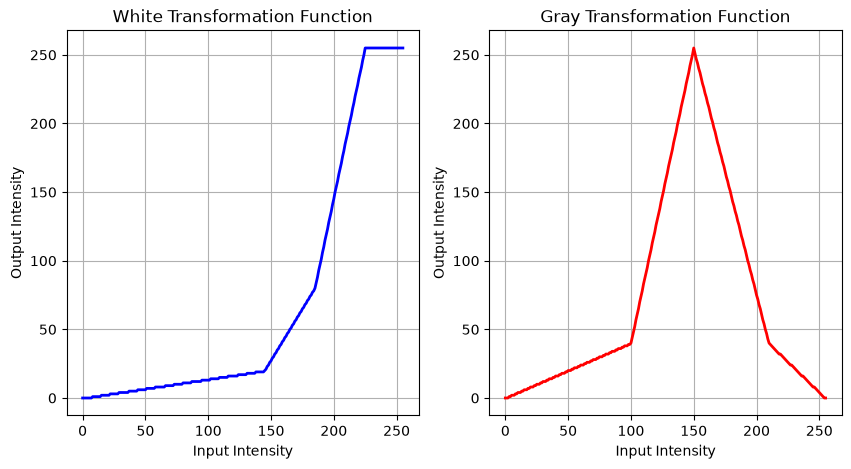

In [84]:
f = cv.imread('images/brain.jpeg')
white_points = [(0, 0), (145, 20), (185, 80), (225, 255),(255, 255)]
gray_points = np.array([(0, 0),(100, 40),(150, 255),(210, 40),(255, 0)])

white_t = transform(white_points)
gray_t  = transform(gray_points)

white_transformed = cv.LUT(f, white_t)
gray_transformed  = cv.LUT(f, gray_t)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(f)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(white_transformed)
ax[1].set_title('White Transformation')
ax[1].axis('off')
ax[2].imshow(gray_transformed)
ax[2].set_title('Gray Transformation')
ax[2].axis('off')
fig,ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(np.arange(256), white_t, 'b-', linewidth=2)
ax[0].set_title('White Transformation Function')
ax[0].grid()
ax[0].set_xlabel('Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[1].plot(np.arange(256), gray_t, 'r-', linewidth=2)
ax[1].set_title('Gray Transformation Function')
ax[1].grid()
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')



White matter: The intensity transformation increases the contrast in the brighter regions of the brain, making the white matter more distinguishable from surrounding tissue.

Gray matter: The transformation enhances the intensity range associated with gray matter. The breakpoints were adjusted to avoid excessive saturation and preserve the visibility of other brain structures.

## Question 3

(np.float64(-0.5), np.float64(719.5), np.float64(479.5), np.float64(-0.5))

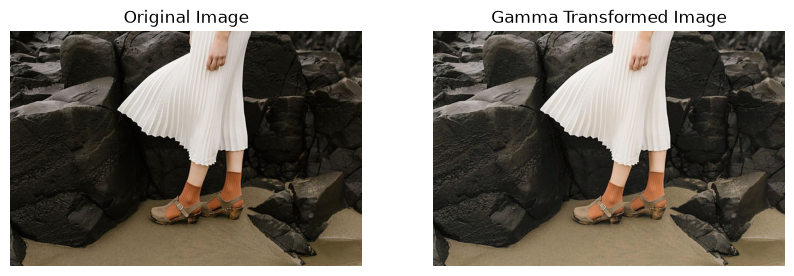

In [85]:
f= cv.imread('images/gamma.jpeg')
L,a,b = cv.split(cv.cvtColor(f, cv.COLOR_BGR2Lab))
gamma = 0.75
L=np.array(255 * (L / 255) ** gamma, dtype=np.uint8)
gamma_transformed = cv.cvtColor(cv.merge((L,a,b)), cv.COLOR_Lab2BGR)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv.cvtColor(f, cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(cv.cvtColor(gamma_transformed, cv.COLOR_BGR2RGB))
ax[1].set_title('Gamma Transformed Image')
ax[1].axis('off')


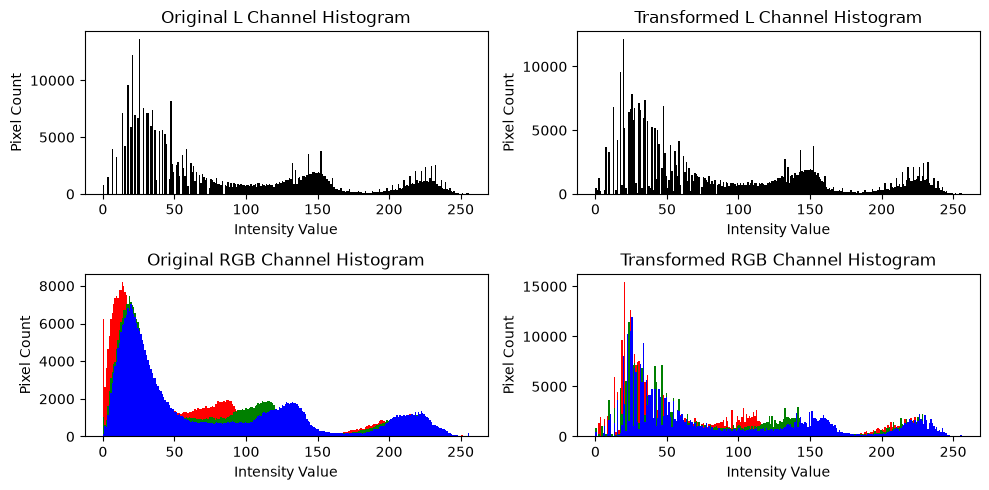

In [86]:
L_transformed = cv.split(cv.cvtColor(gamma_transformed, cv.COLOR_BGR2Lab))[0]
R,G,B = cv.split(f)
R_transformed,G_transformed,B_transformed = cv.split(gamma_transformed)
fig, ax = plt.subplots(2, 2, figsize=(10, 5))
ax[0, 0].hist(L.ravel(), bins=256, range=(0, 256), color='black')
ax[0, 0].set_title('Original L Channel Histogram')
ax[0, 1].hist(L_transformed.ravel(), bins=256, range=(0, 256), color='black')
ax[0, 1].set_title('Transformed L Channel Histogram')
ax[1, 0].hist(R.ravel(), bins=256, range=(0, 256), color='red')
ax[1, 0].set_title('Original R Channel Histogram')
ax[1, 1].hist(R_transformed.ravel(), bins=256, range=(0, 256), color='red')
ax[1, 1].set_title('Transformed R Channel Histogram')
ax[1, 0].hist(G.ravel(), bins=256, range=(0, 256), color='green')
ax[1, 0].set_title('Original G Channel Histogram')
ax[1, 1].hist(G_transformed.ravel(), bins=256, range=(0, 256), color='green')
ax[1, 1].set_title('Transformed G Channel Histogram')
ax[1, 0].hist(B.ravel(), bins=256, range=(0, 256), color='blue')
ax[1, 0].set_title('Original RGB Channel Histogram')
ax[1, 1].hist(B_transformed.ravel(), bins=256, range=(0, 256), color='blue')
ax[1, 1].set_title('Transformed RGB Channel Histogram')
ax[0, 0].set_xlabel('Intensity Value')
ax[0, 0].set_ylabel('Pixel Count')
ax[0, 1].set_xlabel('Intensity Value')
ax[0, 1].set_ylabel('Pixel Count')
ax[1, 0].set_xlabel('Intensity Value')
ax[1, 0].set_ylabel('Pixel Count')
ax[1, 1].set_xlabel('Intensity Value')
ax[1, 1].set_ylabel('Pixel Count')
plt.tight_layout()


The histogram of the corrected image appears noisier because gamma correction is a non-linear operation. When applied to the L plane, which represents lightness in the LAB colour space, it can amplify small differences in pixel intensity. Since pixel values are discrete, the non-linear transformation redistributes them unevenly, causing quantisation noise and a noisier histogram.

## Question 4

(np.float64(-0.5), np.float64(779.5), np.float64(437.5), np.float64(-0.5))

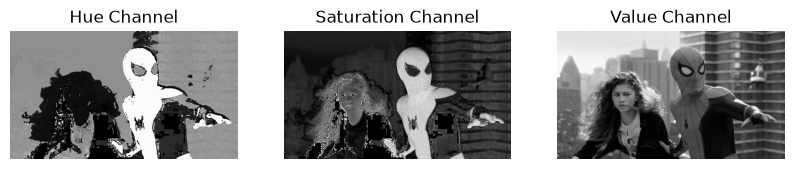

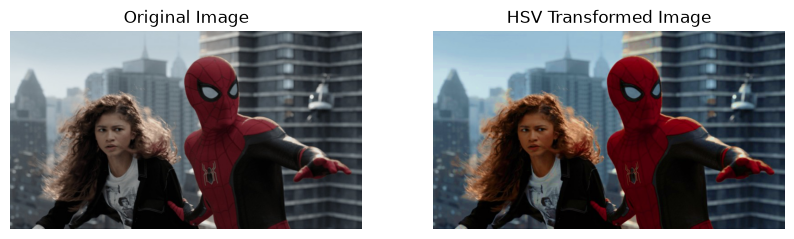

In [94]:
f= cv.imread('images/spider_man.jpeg')
H,S,V = cv.split(cv.cvtColor(f, cv.COLOR_BGR2HSV))
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(H,cmap='gray')
ax[0].set_title('Hue Channel')
ax[0].axis('off')
ax[1].imshow(S, cmap='gray')
ax[1].set_title('Saturation Channel')
ax[1].axis('off')
ax[2].imshow(V, cmap='gray')
ax[2].set_title('Value Channel')
ax[2].axis('off')
sigma = 70
a = 0.8
x = np.arange(256)
t = x + a * 128 * np.exp(-(x - 128)**2 / (2 * sigma**2))
t = np.minimum(t, 255).astype(np.uint8)
S_transformed = t[S]
hsv_transformed = cv.merge([H, S_transformed, V])
vibrance_enhanced = cv.cvtColor(hsv_transformed, cv.COLOR_HSV2RGB)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(cv.cvtColor(f, cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(vibrance_enhanced)
ax[1].set_title(f'Vibrance-Enhanced Image (a = {a})')
ax[1].axis('off')

ax[2].plot(x, t, color='purple', linewidth=2, label='Transformation')
ax[2].plot(x, x, '--', color='gray', label='Identity')
ax[2].set_title('Saturation Intensity Transformation')
ax[2].set_xlabel('Input Saturation')
ax[2].set_ylabel('Output Saturation')
ax[2].set_xlim(0, 255)
ax[2].set_ylim(0, 255)
ax[2].grid(alpha=0.3)
ax[2].legend()
fig.tight_layout()
plt.show()